In [2]:
import pandas as pd
import numpy as np
import pickle
import obspy
from seismicif.datamod.loading_utils import (
    find_paths,
    preproc_flow_annotations,
    find_date_in_strings,
    extract_split_flows,
    extract_template,
    read_segment,
    remove_duplicate_traces,
    remove_overlaps,
    sliding_windows_from_trace,
    limit_segment_length,
)
from seismicif.datamod.preproc_utils import preproc_stream
from seismicif.metrics import iou
from seismicif.dtw import segment_dtw
from joblib import dump, load
from datetime import timedelta
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform


def find_fp_fn(df, gt):
    if len(df) == 0:
        FP = np.nan
        FN = gt

    else:
        I, U, _ = iou(df, gt)
        FP = df.iloc[np.where(np.append(I[0], np.diff(I)) == 0)[0], :]

        I, U, _ = iou(gt, df)
        FN = gt.iloc[np.where(np.append(I[0], np.diff(I)) == 0)[0], :]

    return FP, FN


def normalize_stream_to_unit_range(stream: obspy.Stream) -> obspy.Stream:
    """
    Normalize all traces in an ObsPy Stream so that each trace's data
    lies in the range [0, 1].
    """
    normed_stream = stream.copy()
    for tr in normed_stream:
        data = tr.data.astype(np.float64)
        min_val = np.min(data)
        max_val = np.max(data)
        if max_val != min_val:  # avoid division by zero
            tr.data = (data - min_val) / (max_val - min_val)
        else:
            tr.data = np.zeros_like(data)  # or leave as-is
    return normed_stream

In [31]:
with open(f"../output/DK/dtw/info/NUUG.pkl", "rb") as f:
    info = pickle.load(f)

In [32]:
indices = info[0]
d = np.array([np.median(i[0]) for i in info[1]])

D = np.zeros([50, 50])

for n in range(len(indices)):
    i, j = indices[n]

    D[i, j] = d[n]

D = D + D.T

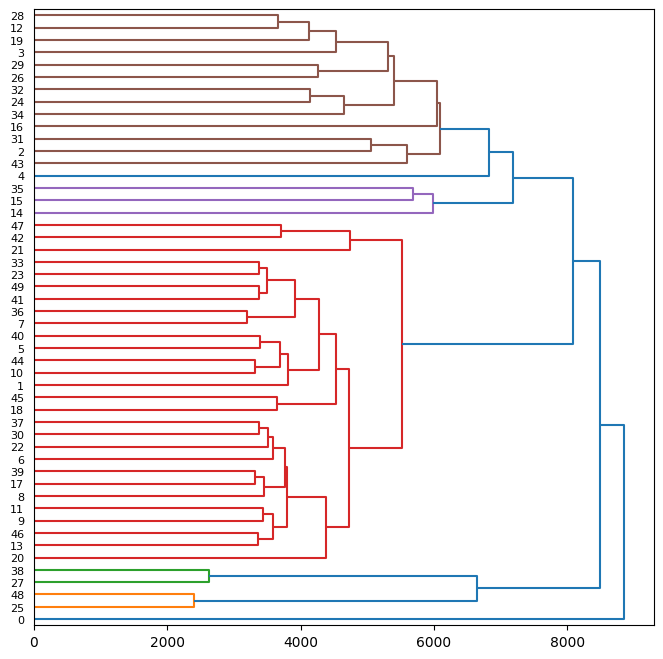

In [33]:
Z = linkage(squareform(D), method="complete")
plt.figure(figsize=(8, 8))
dendrogram(Z, orientation="right")
plt.show()

In [34]:
with open(f"../output/DK/dtw/info/KARAT.pkl", "rb") as f:
    info = pickle.load(f)

In [35]:
labs = np.array(pd.read_csv("../catalogs/DK/KARAT.csv", index_col=0)["labels"])

for i in range(labs.shape[0]):
    labs[i] = labs[i] + "  " + str(i)

In [42]:
indices = info[0]
d = np.array([np.median(i[0]) for i in info[1]])

In [43]:
D = np.zeros([50, 50])

for n in range(len(indices)):
    i, j = indices[n]

    D[i, j] = d[n]

D = D + D.T

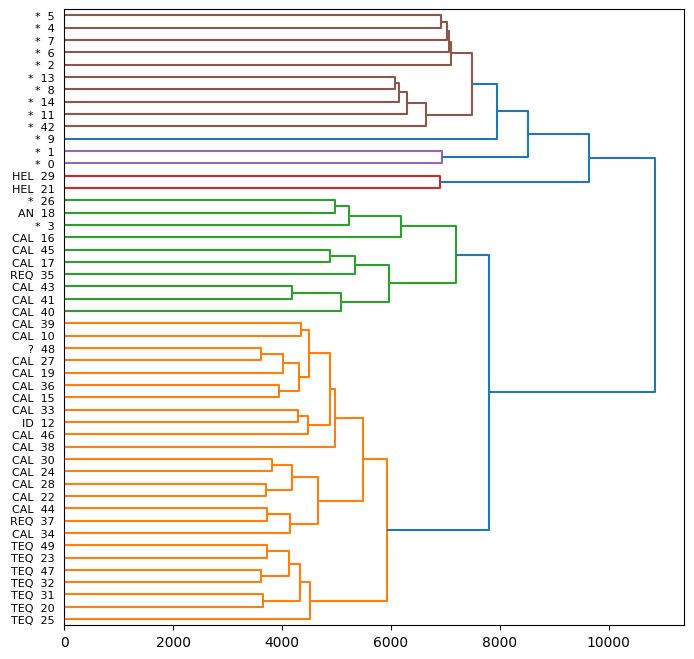

In [44]:
Z = linkage(squareform(D), method="complete")
plt.figure(figsize=(8, 8))
dendrogram(Z, orientation="right", labels=labs)
plt.show()

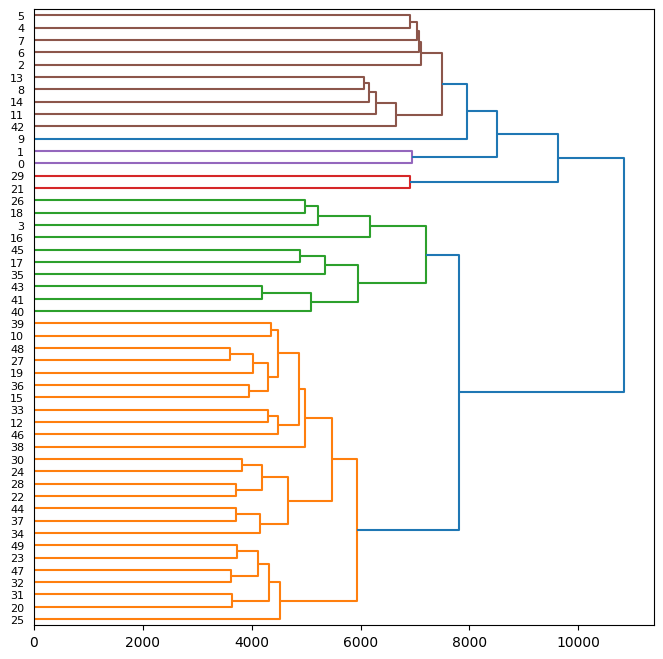

In [ ]:
Z = linkage(squareform(D), method="complete")
plt.figure(figsize=(8, 8))
dendrogram(Z, orientation="right")
plt.show()

In [ ]:
# def limit_segment_length(
#     t0, t1, paths, if_mod, max_len=3600, window_size=10000, stride=10000
# ):
#     tr = read_segment(t0, t1, paths)
#     X, T = sliding_windows_from_trace(tr, window_size=window_size, stride=stride)
#     if_scores = -if_mod.score_samples(X)

#     idx_low = np.argmax(if_scores)
#     idx_high = np.argmax(if_scores)

#     while True:
#         seg_length = T[idx_high][1] - T[idx_low][0]
#         if seg_length >= max_len:
#             break

#         if idx_low == 0 and idx_high == len(if_scores) - 1:
#             break

#         if idx_low == 0:
#             idx_high += 1
#         elif idx_high == len(if_scores) - 1:
#             idx_low -= 1
#         elif if_scores[idx_high + 1] > if_scores[idx_low - 1]:
#             idx_high += 1
#         else:
#             idx_low -= 1

#     X = X[idx_low : idx_high + 1]
#     if_scores = if_scores[idx_low : idx_high + 1]
#     start = T[idx_low][0]
#     stop = T[idx_high][1]

#     return X, if_scores, start, stop

In [3]:
paths = find_paths("DK", "NUUG", "HHZ.D", 2017, 2017)
if_mod = load(f"../output/DK/if/models/NUUG.joblib")
segments = preproc_flow_annotations(
    pd.read_csv("../output/DK/if/segments/NUUG.csv", index_col=0)
)

In [4]:
print(segments.iloc[9, 0], segments.iloc[9, 1])

2017-06-26T02:57:31.680001Z 2017-06-28T09:58:21.680001Z


In [5]:
seg2 = limit_segment_length(
    segments.iloc[9, 0], segments.iloc[9, 1], paths, if_mod, max_len=3600, stride=10000
)

In [7]:
seg2[0].shape[0]

36

In [6]:
seg2

(array([[  35.86110077,   14.50415907,   48.2027198 , ..., -120.77213156,
         -101.12539898,  -97.52428323],
        [-126.96795582, -139.45557519,  -83.98628706, ...,  -83.48961554,
          -53.09328766,  -56.76841673],
        [ -77.51523413,  -74.33395094,  -81.22475786, ...,  103.18639035,
          102.03618941,  125.87527655],
        ...,
        [-178.50673066, -188.52181734, -183.64752468, ...,  -68.39824195,
          -33.15556656,  -21.93372032],
        [ -28.73264439,   -9.55227164,  -21.39252681, ...,   32.82532336,
           25.11558469,    8.45904875],
        [  17.85693754,   25.31045777,   43.82080033, ..., -325.64203329,
         -352.31803748, -323.09979579]]),
 array([0.66812422, 0.66147277, 0.64326456, 0.64903584, 0.65722104,
        0.64933457, 0.64468697, 0.66468771, 0.65969724, 0.65069763,
        0.63152335, 0.69228237, 0.64589732, 0.64456621, 0.66840596,
        0.66437886, 0.65115922, 0.65212266, 0.65853439, 0.67644709,
        0.62895125, 0.6711862

In [11]:
seg2 = limit_segment_length(
    segments.iloc[9, 0], segments.iloc[9, 1], paths, if_mod, max_len=3600, stride=5000
)

In [12]:
seg2

(array([[ 174.67996861,  147.64531465,  141.60500714, ...,  -31.64775229,
          -21.90249148,  -18.10391307],
        [ -48.04101387,  -47.93029959,  -41.74953404, ...,  359.83484208,
          386.57411747,  389.35470281],
        [ -19.25257341,  -19.3490443 ,   14.60608707, ..., -120.29918247,
         -136.04043176, -118.77984967],
        ...,
        [ 322.76034228,  331.69266905,  342.7206945 , ...,  114.10080133,
          105.53394968,   84.04360189],
        [-100.71876379, -110.3242073 , -113.86574741, ...,   96.46607679,
          131.79399692,  130.18164235],
        [  91.629911  ,   85.2930021 ,   78.03297235, ...,   82.49804399,
           59.55496752,   81.62116253]]),
 array([0.66282144, 0.66437886, 0.67432076, 0.65115922, 0.65242424,
        0.65212266, 0.65891343, 0.65853439, 0.66519602, 0.67644709,
        0.65941864, 0.62895125, 0.63776457, 0.67118623, 0.65701446,
        0.65598953, 0.62664226, 0.65492747, 0.61293942, 0.64132229,
        0.70242546, 0.6578209

In [13]:
seg2[0].shape[0]

71

3550

In [4]:
seg1 = limit_segment_length(segments.iloc[2, 0], segments.iloc[2, 1], paths, if_mod)
seg2 = limit_segment_length(segments.iloc[9, 0], segments.iloc[9, 1], paths, if_mod)

In [5]:
seg2[0].shape

(37, 10000)

In [6]:
seg2

(array([[  35.86110077,   14.50415907,   48.2027198 , ..., -120.77213156,
         -101.12539898,  -97.52428323],
        [-126.96795582, -139.45557519,  -83.98628706, ...,  -83.48961554,
          -53.09328766,  -56.76841673],
        [ -77.51523413,  -74.33395094,  -81.22475786, ...,  103.18639035,
          102.03618941,  125.87527655],
        ...,
        [ -28.73264439,   -9.55227164,  -21.39252681, ...,   32.82532336,
           25.11558469,    8.45904875],
        [  17.85693754,   25.31045777,   43.82080033, ..., -325.64203329,
         -352.31803748, -323.09979579],
        [-354.98767108, -338.98198848, -346.08303519, ..., -157.78428996,
         -147.15483207, -163.64618953]]),
 array([0.66812422, 0.66147277, 0.64326456, 0.64903584, 0.65722104,
        0.64933457, 0.64468697, 0.66468771, 0.65969724, 0.65069763,
        0.63152335, 0.69228237, 0.64589732, 0.64456621, 0.66840596,
        0.66437886, 0.65115922, 0.65212266, 0.65853439, 0.67644709,
        0.62895125, 0.6711862

In [14]:
dtw_dists, path = segment_dtw(seg1, seg2)

In [15]:
np.median(dtw_dists)

6691.601698493255

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from obspy import Stream, Trace
from scipy.signal import spectrogram as scipy_spectrogram


def plot_waveforms_and_spectrograms(
    data, wlen=10, log=False, figsize=(12, 4), cmap="viridis", save_path=None
):
    # Normalize input
    if isinstance(data, Trace):
        data = Stream(traces=[data])
    elif not isinstance(data, Stream):
        raise TypeError("Input must be an ObsPy Stream or Trace.")

    n = len(data)

    # Compute all spectrograms and find global min/max
    spectrograms = []
    global_min, global_max = np.inf, -np.inf

    for tr in data:
        fs = tr.stats.sampling_rate
        nperseg = int(wlen * fs)
        f, t, Sxx = scipy_spectrogram(tr.data, fs=fs, nperseg=nperseg)
        if log:
            Sxx = 10 * np.log10(Sxx + 1e-10)
        spectrograms.append((f, t, Sxx))
        global_min = min(global_min, Sxx.min())
        global_max = max(global_max, Sxx.max())

    # Create subplots (always 2 columns: waveform + spectrogram)
    fig, axes = plt.subplots(n, 2, figsize=(figsize[0], figsize[1] * n))

    # Normalize axes to always be 2D array-like
    if n == 1:
        axes = [axes]  # single row of 2 axes -> wrap in list

    for i, tr in enumerate(data):
        ax_wave, ax_spec = axes[i]

        # Plot waveform
        times = tr.times()
        ax_wave.plot(times, tr.data, "k")
        ax_wave.set_title(f"{tr.id} — {tr.stats.starttime.date}")
        for label in ax_wave.get_xticklabels():
            label.set_rotation(30)
            label.set_horizontalalignment("right")

        # Plot spectrogram with fixed color scale
        f, t, Sxx = spectrograms[i]
        im = ax_spec.pcolormesh(
            t, f, Sxx, shading="gouraud", cmap=cmap, vmin=global_min, vmax=global_max
        )
        ax_spec.set_ylabel("Frequency [Hz]")
        ax_spec.set_xlabel("Time [s]")
        ax_spec.set_title(f"{tr.id}")

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Power")

    # Adjust layout
    fig.subplots_adjust(right=0.9, hspace=0.5)

    if save_path:
        fig.savefig(save_path)
        print(f"Saved to {save_path}")

    plt.show()
    return fig

In [116]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
)
confirmed_FP = preproc_flow_annotations(pd.read_csv("../catalogs/XP/confirmed_FP.csv"))
to_confirm = preproc_flow_annotations(pd.read_csv("../catalogs/XP/to_confirm.csv"))

remove_dict = {}
for station in ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]:
    remove_dict[station] = pd.concat(
        [
            confirmed_FP[confirmed_FP["station"] == station].iloc[:, [0, 1, 2, 5]],
            to_confirm[to_confirm["station"] == station],
        ]
    ).reset_index(drop=True)

In [119]:
stations = ["ILL11", "ILL12", "ILL13", "ILL18"]
if_detections = {}
sta_lta_detections = {}
dtw_detections = {}

for station in stations:
    if_detections[station] = pd.read_csv(
        f"../output/XP/if/detections/{station}.csv", index_col=0
    )
    sta_lta_detections[station] = pd.read_csv(
        f"../output/XP/sta_lta/detections/{station}.csv", index_col=0
    )

stations = ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]

for station in stations:
    dtw_detections[station] = pd.read_csv(
        f"../output/XP/if_dtw/detections/{station}.csv", index_col=0
    )

In [120]:
IF_FP = {}
STA_LTA_FP = {}
DTW_FP = {}
for station in ["ILL11", "ILL12", "ILL13", "ILL18"]:
    _, _, station_flows = extract_split_flows(flows, station, 2018, 2022)
    IF_FP[station] = find_fp_fn(if_detections[station], station_flows)[0].reset_index(
        drop=True
    )
    STA_LTA_FP[station] = find_fp_fn(sta_lta_detections[station], station_flows)[
        0
    ].reset_index(drop=True)

for station in ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]:
    _, _, station_flows = extract_split_flows(flows, station, 2018, 2022)
    DTW_FP[station] = find_fp_fn(dtw_detections[station], station_flows)[0].reset_index(
        drop=True
    )

In [121]:
if_unconfirmed = {}

for station in ["ILL11", "ILL12", "ILL13", "ILL18"]:
    FP = find_fp_fn(IF_FP[station], remove_dict[station])[0]

    if FP is np.nan:
        continue

    if len(FP) == 0:
        continue

    if_unconfirmed[station] = FP.reset_index(drop=True)

In [122]:
sta_lta_unconfirmed = {}

for station in ["ILL11", "ILL12", "ILL13", "ILL18"]:
    FP = find_fp_fn(STA_LTA_FP[station], remove_dict[station])[0]

    if FP is np.nan:
        continue

    if len(FP) == 0:
        continue

    sta_lta_unconfirmed[station] = FP.reset_index(drop=True)

In [123]:
dtw_unconfirmed = {}
for station in ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]:
    FP = find_fp_fn(DTW_FP[station], remove_dict[station])[0]

    if FP is np.nan:
        continue

    if len(FP) == 0:
        continue

    dtw_unconfirmed[station] = FP.reset_index(drop=True)

In [124]:
to_confirm

,station,start,stop,source,remarks
0,ILL14,2022-06-13T22:53:34.000000Z,2022-06-13T22:58:34.000000Z,DTW,event effecting the upper stations only...rock...
1,ILL17,2022-06-08T12:37:42.650000Z,2022-06-08T12:53:32.650000Z,DTW,upper catchment activity?
2,ILL17,2022-06-28T13:17:42.650000Z,2022-06-28T13:41:52.650000Z,DTW,upper catchment activity?
3,ILL17,2020-06-24T19:36:59.960000Z,2020-06-24T19:55:19.960000Z,DTW,possible upper catchment activity...quiet on I...
4,ILL17,2022-08-13T05:31:52.650000Z,2022-08-13T06:31:02.650000Z,DTW,somewhat quiet on ILL17 and other stations
5,ILL17,2022-07-07T13:06:02.650000Z,2022-07-07T13:32:42.650000Z,DTW,possible upper catchment activity...quiet on I...
6,ILL18,2021-08-11T05:10:58.680000Z,2021-08-11T06:10:09.120000Z,STA-LTA,possible upper catchment activity at the begin...
7,ILL18,2021-05-01T17:55:32.710000Z,2021-05-01T19:58:31.680000Z,STA-LTA,Only ILL18 active...perhaps noise
8,ILL18,2021-08-16T11:14:36.390000Z,2021-08-16T11:59:23.130000Z,STA-LTA,South Sandwich Islands region experienced mult...
9,ILL18,2021-07-20T06:45:33.920000Z,2021-07-20T09:35:20.730000Z,STA-LTA,possible upper catchment activity


In [125]:
for station in sta_lta_unconfirmed:
    print(station, sta_lta_unconfirmed[station])

In [126]:
for station in dtw_unconfirmed:
    print(station, dtw_unconfirmed[station])

In [127]:
for station in if_unconfirmed:
    print(station, if_unconfirmed[station])

In [158]:
# ILL18: 2021-04-21T09:10:02.560000Z  2021-04-21T10:01:53.500000Z ~ difficult one since only ILL18 is active...perhaps activity...check for earthquakes


In [159]:
# seg = sta_lta_unconfirmed["ILL18"].iloc[0]
# seg = dtw_unconfirmed["ILL14"].iloc[0]
# seg = dtw_unconfirmed["ILL17"].iloc[0]
# seg = FP.iloc[29]
# # np.where(FP["Labels"] == "HEL")
# #seg = ILL17_flows.iloc[2]
# #np.where(FP["Labels"] == "MS")
# np.where(FP["Labels"] == "AN")

In [ ]:
# dt = str(seg["start"])[:10]
# time_b = timedelta(seconds=5*60)
# time_t = timedelta(seconds=0*60)

# streams = obspy.Stream()
# t0 = obspy.UTCDateTime(seg["start"]) - time_b
# t1 = obspy.UTCDateTime(seg["stop"]) + time_t
# #t1 = obspy.UTCDateTime(seg["start"]) + time_b

# # t0 = obspy.UTCDateTime("2019-04-06T08:58:03.910000Z")
# # # t0 = obspy.UTCDateTime("2021-08-16T11:15:00.390000Z")
# # t1 = obspy.UTCDateTime("2021-04-11T11:15:44.420000Z")

# for station in ["ILL11","ILL12","ILL13","ILL14","ILL15","ILL16","ILL17","ILL18"]:
#     channel = "EHZ.D"

#     if station == "ILL11":
#         channel = "HHZ.D"
#     try:
#         paths = find_paths("XP", station, channel, 2018, 2022)
#         p = find_date_in_strings(paths, dt)[0]
#         st = obspy.read(p)
#         st = remove_overlaps(st)
#         st = remove_duplicate_traces(st)
#         preproc_stream(st)
#         st.trim(t0, t1)
#         #streams += st
#         streams += normalize_stream_to_unit_range(st)

#     except:
#         continue



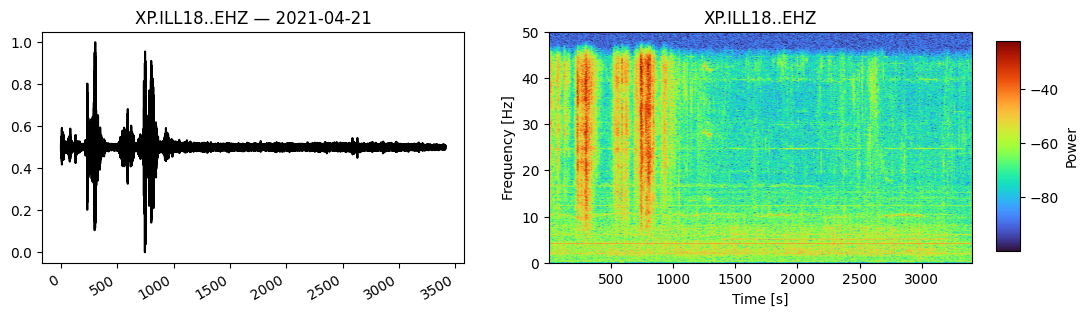

In [ ]:
# fig =plot_waveforms_and_spectrograms(streams,figsize=(12, 3),log=True,cmap="turbo")